In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('house_prices_practice.csv')
df.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [4]:
print(df.corr()['SalePrice'].sort_values(ascending=False))

SalePrice       1.000000
GrLivArea       0.745095
OverallQual     0.352899
GarageCars      0.351321
FullBath        0.273731
TotalBsmtSF     0.250178
YearBuilt       0.222142
BedroomAbvGr    0.014113
Id             -0.025416
LotArea        -0.038982
Name: SalePrice, dtype: float64


In [5]:
df=df.drop('Id',axis=1)

In [6]:
df.isnull().sum()

OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64

In [7]:
df = df.fillna(df.mean(numeric_only=True))

In [8]:
df = pd.get_dummies(df, drop_first=True)

In [9]:
from sklearn.model_selection import train_test_split
X=df.drop('SalePrice',axis=1)
y=df['SalePrice']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor(n_estimators=200)
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [11]:
from sklearn.metrics import r2_score
y_pred=model.predict(X_test)
print("r2 score",r2_score(y_test,y_pred))

r2 score 0.8762314013977728


In [12]:
print(y_pred)

[215432.85  192637.67  345218.12  217206.025 155340.33  189353.785
 258541.805 211025.19  201750.005 198751.625 346470.4   281059.255
 146187.13  169328.535 296166.01  322107.82  141540.705 149611.295
 210414.24  259449.4   273512.1   157937.675 269532.675 256660.705
 318366.99  311816.565 190961.01  272432.185 280439.935 383662.32
 373652.175 279151.64  140220.465 213580.72  292956.33  228335.775
 344960.26  290220.89  241960.85  170743.515 211946.64  314897.5
 300251.335 282242.06  350401.125 317524.695 207370.73  236102.01
 213785.255 315597.4   330217.625 310919.03  141198.96  263990.62
 199491.955 267672.33  194130.745 316045.595 269689.375 173094.44 ]


In [15]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)
predictions=model.predict(X_test)
print(predictions)
print('r2score',r2_score(y_test,predictions))

[239161.36318913 190489.66798468 398000.95746314 223169.46755225
 135188.39570786 180259.03980676 283708.27101141 204535.26547718
 205837.94173062 171505.33195999 389527.70178374 274163.79739932
 116220.90212357 171343.53163323 293879.43188669 314821.03156748
 154945.46275533 146162.96860438 221221.02813414 255128.9486496
 235772.5157203  167430.5426685  208978.16707484 289813.4757898
 313188.74897607 382651.91313186 206610.720434   260775.03716678
 285214.27337024 443345.98671709 402224.27697766 292287.65157278
 122222.0857363  211039.07225072 291045.64445758 226581.77285369
 342146.60151078 243378.66853477 235856.80880212 201521.50903895
 237379.06138588 334582.4670175  313689.69084594 292464.38340658
 376959.34215332 319400.67913445 217324.69316316 256908.21155235
 218997.8110662  332431.87339145 305659.98833244 321564.58478164
 110394.39792686 304824.1326228  202320.80190839 272444.61942839
 178702.26077918 334291.06264612 292853.7802179  139984.44761657]
r2score 0.9724369952260798

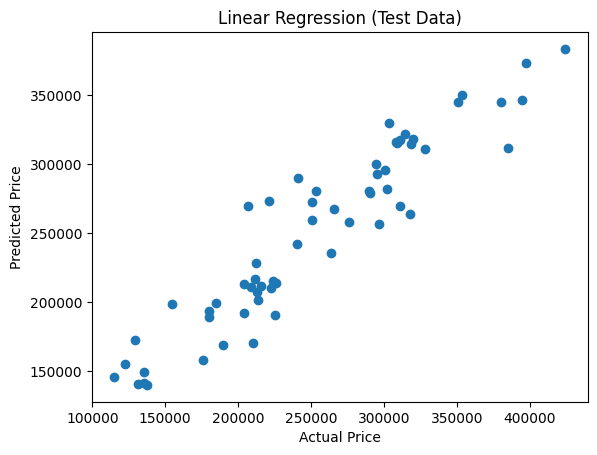

In [19]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression (Test Data)")

plt.show()

In [20]:
from xgboost import XGBRegressor
model=XGBRegressor()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(y_pred)
print("r2 score",r2_score(y_test,y_pred))

[220861.77 201033.05 362170.53 222998.31 134543.33 195918.7  235066.88
 210341.3  176488.86 200162.86 329869.03 294601.44 143888.1  162795.98
 287078.4  331112.44 153673.48 167619.06 228877.77 267778.3  270992.25
 167878.48 257673.02 280247.94 322975.12 323345.16 176388.38 279932.75
 315315.   408499.38 372084.   290506.34 132503.86 205046.19 276629.53
 213463.88 360595.7  286219.03 263089.25 168202.58 217433.45 314646.3
 278250.   294750.84 358261.78 315990.97 208604.22 268080.7  199210.03
 322121.12 316598.44 301693.4  151802.16 267502.3  203967.75 256331.06
 179772.11 334801.38 248226.23 160695.03]
r2 score 0.8654612302780151


In [21]:
'-------USER INPUT-----------'
area = float(input("Enter living area: "))
quality = int(input("Enter overall quality (1-10): "))
garage = int(input("Enter garage cars: "))
bath = int(input("Enter full bathrooms: "))
year = int(input("Enter year built: "))

Enter living area:  4560.23
Enter overall quality (1-10):  8
Enter garage cars:  2
Enter full bathrooms:  3
Enter year built:  1990


In [22]:
import pandas as pd

input_data = pd.DataFrame([{
    'GrLivArea': area,
    'OverallQual': quality,
    'GarageCars': garage,
    'FullBath': bath,
    'YearBuilt': year
}])

In [23]:
input_data = input_data.reindex(columns=X.columns, fill_value=0)

In [24]:
prediction = model.predict(input_data)

print(f"Predicted House Price: ₹{prediction[0]:,.2f}")

Predicted House Price: ₹373,141.75
